In [1]:
# ============================================================
# 1. LOAD DATA EXCEL
# ============================================================

from google.colab import drive
import pandas as pd

# mount drive
drive.mount('/content/drive')

# load data
makro_2010_2024 = pd.read_excel("/content/drive/My Drive/Data Inflasi, BI Rate, Kurs.xlsx")
kurs = makro_2010_2024[['Tanggal', 'Data Kurs']]
# preview
makro_2010_2024.head()
kurs.head()

Mounted at /content/drive


,Tanggal,Data Kurs
0,2010-01-01,9350.0
1,2010-02-01,9337.0
2,2010-03-01,9090.0
3,2010-04-01,9012.5
4,2010-05-01,9175.0


In [2]:
# ============================================================
# 2. IMPORT LIBRARY
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import tensorflow as tf
import random

# supaya hasil lebih stabil / reproducible
seed = 123
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

In [3]:
# ============================================================
# 3. RAPIIKAN DATA
# ============================================================

# copy data agar aman
df = kurs.copy()

# ubah kolom tanggal ke format datetime
df["Tanggal"] = pd.to_datetime(df["Tanggal"])

# urutkan berdasarkan tanggal
df = df.sort_values("Tanggal").reset_index(drop=True)

# cek nama kolom
print(df.columns)

# pilih hanya kolom yang dipakai
macro_cols = ["Data Kurs"]

# pastikan semua kolom numerik
for col in macro_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# hapus missing value jika ada
df = df.dropna(subset=["Tanggal"] + macro_cols).reset_index(drop=True)

# lihat data akhir
print(df.head())
print(df.tail())
print(df.shape)

Index(['Tanggal', 'Data Kurs'], dtype='object')
     Tanggal  Data Kurs
0 2010-01-01     9350.0
1 2010-02-01     9337.0
2 2010-03-01     9090.0
3 2010-04-01     9012.5
4 2010-05-01     9175.0
       Tanggal  Data Kurs
175 2024-08-01    15450.0
176 2024-09-01    15135.0
177 2024-10-01    15690.0
178 2024-11-01    15840.0
179 2024-12-01    16090.0
(180, 2)


In [4]:
# ============================================================
# 4. FUNGSI MEMBUAT SEQUENCE LSTM
# ============================================================

def create_sequences(series, look_back=4):
    """
    Mengubah data time series menjadi format supervised learning:
    X = sebanyak 'look_back' periode sebelumnya
    y = nilai pada periode berikutnya
    """
    X, y = [], []
    for i in range(look_back, len(series)):
        X.append(series[i-look_back:i, 0])
        y.append(series[i, 0])
    X = np.array(X)
    y = np.array(y)
    return X, y

In [5]:
# ============================================================
# 5. FUNGSI MEMBUAT MODEL LSTM (VERSI OPTIMASI)
# ============================================================

def build_lstm_model(look_back=4, n_features=1):
    model = Sequential()

    # layer LSTM pertama - Dikurangi unitnya agar tidak terlalu kompleks
    model.add(LSTM(64, activation="tanh", return_sequences=False,
                   input_shape=(look_back, n_features)))

    model.add(Dropout(0.2))

    # Note: hapus layer LSTM kedua karena untuk data makro-saham bulanan,
    # 1 layer biasanya jauh lebih stabil dan mencegah gradien meledak.

    # output layer
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=0.001), loss="mse")

    return model

In [6]:
# ============================================================
# 6. TRAIN + TEST + RETRAIN FINAL + FORECAST 2025
#    + EVALUASI TRAINING AWAL
#    UNTUK SETIAP VARIABEL
# ============================================================

look_back = 4
test_size = 12              # 12 bulan terakhir untuk testing (tahun 2024)
epochs = 200
batch_size = 1

forecast_dict = {}

# evaluasi model awal
eval_train_results = []
eval_test_results = []

# evaluasi model final
eval_final_train_results = []

history_dict = {}
model_dict = {}
scaler_dict = {}

train_plot_dict = {}
test_plot_dict = {}
final_train_plot_dict = {}

for col in macro_cols:
    print("="*70)
    print(f"Proses variabel: {col}")

    # --------------------------------------------------------
    # ambil 1 variabel
    # --------------------------------------------------------
    series_df = df[["Tanggal", col]].copy().dropna().reset_index(drop=True)
    values = series_df[[col]].values.astype(float)

    # --------------------------------------------------------
    # pisahkan data:
    # train awal = 2010-2023
    # test       = 2024
    # full       = 2010-2024
    # --------------------------------------------------------
    train_values = values[:-test_size]
    test_values  = values[-test_size:]
    full_values  = values

    # --------------------------------------------------------
    # scaling untuk model evaluasi
    # scaler hanya fit di data training 2010-2023
    # --------------------------------------------------------
    scaler_train = MinMaxScaler(feature_range=(0, 1))
    scaler_train.fit(train_values)

    scaled_all = scaler_train.transform(values)
    scaler_dict[f"{col}_train"] = scaler_train

    # --------------------------------------------------------
    # buat sequence untuk evaluasi model awal
    # --------------------------------------------------------
    X_all, y_all = create_sequences(scaled_all, look_back=look_back)
    X_all = X_all.reshape((X_all.shape[0], X_all.shape[1], 1))

    # sequence training dan testing
    X_train = X_all[:-test_size]
    y_train = y_all[:-test_size]

    X_test = X_all[-test_size:]
    y_test = y_all[-test_size:]

    print("Shape X_train:", X_train.shape)
    print("Shape X_test :", X_test.shape)

    # --------------------------------------------------------
    # bangun model evaluasi
    # --------------------------------------------------------
    model = build_lstm_model(look_back=look_back)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )

    # --------------------------------------------------------
    # training model evaluasi
    # --------------------------------------------------------
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        shuffle=False,
        callbacks=[early_stop]
    )

    history_dict[f"{col}_eval"] = history
    model_dict[f"{col}_eval"] = model

    # ========================================================
    # A. EVALUASI TRAINING (MODEL 2010-2023)
    # ========================================================
    y_pred_train_scaled = model.predict(X_train, verbose=0)

    y_train_actual = scaler_train.inverse_transform(y_train.reshape(-1, 1)).flatten()
    y_pred_train_actual = scaler_train.inverse_transform(y_pred_train_scaled).flatten()

    train_dates = series_df["Tanggal"].iloc[look_back:len(series_df)-test_size].reset_index(drop=True)

    train_plot_dict[col] = pd.DataFrame({
        "Tanggal": train_dates,
        "Aktual": y_train_actual,
        "Prediksi": y_pred_train_actual
    })

    mae_train = mean_absolute_error(y_train_actual, y_pred_train_actual)
    rmse_train = np.sqrt(mean_squared_error(y_train_actual, y_pred_train_actual))
    mape_train = np.mean(
        np.where(
            y_train_actual != 0,
            np.abs((y_train_actual - y_pred_train_actual) / y_train_actual),
            np.nan
        )
    ) * 100
    smape_train = np.mean(
        2 * np.abs(y_pred_train_actual - y_train_actual) /
        (np.abs(y_train_actual) + np.abs(y_pred_train_actual) + 1e-8)
    ) * 100
    r2_train = r2_score(y_train_actual, y_pred_train_actual)

    eval_train_results.append({
        "Variabel": col,
        "MAE": mae_train,
        "RMSE": rmse_train,
        "MAPE": mape_train,
        "sMAPE": smape_train,
        "R2": r2_train
    })

    # ========================================================
    # B. EVALUASI TESTING (2024)
    # ========================================================
    y_pred_test_scaled = model.predict(X_test, verbose=0)

    y_test_actual = scaler_train.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_test_actual = scaler_train.inverse_transform(y_pred_test_scaled).flatten()

    test_dates = series_df["Tanggal"].iloc[-test_size:].reset_index(drop=True)

    test_plot_dict[col] = pd.DataFrame({
        "Tanggal": test_dates,
        "Aktual": y_test_actual,
        "Prediksi": y_pred_test_actual
    })

    mae_test = mean_absolute_error(y_test_actual, y_pred_test_actual)
    rmse_test = np.sqrt(mean_squared_error(y_test_actual, y_pred_test_actual))
    mape_test = np.mean(
        np.where(
            y_test_actual != 0,
            np.abs((y_test_actual - y_pred_test_actual) / y_test_actual),
            np.nan
        )
    ) * 100
    smape_test = np.mean(
        2 * np.abs(y_pred_test_actual - y_test_actual) /
        (np.abs(y_test_actual) + np.abs(y_pred_test_actual) + 1e-8)
    ) * 100
    r2_test = r2_score(y_test_actual, y_pred_test_actual)

    eval_test_results.append({
        "Variabel": col,
        "MAE": mae_test,
        "RMSE": rmse_test,
        "MAPE": mape_test,
        "sMAPE": smape_test,
        "R2": r2_test
    })

    # ========================================================
    # C. RETRAIN MODEL FINAL DENGAN DATA 2010-2024
    # ========================================================
    scaler_full = MinMaxScaler(feature_range=(0, 1))
    scaled_full = scaler_full.fit_transform(full_values)
    scaler_dict[f"{col}_full"] = scaler_full

    X_full, y_full = create_sequences(scaled_full, look_back=look_back)
    X_full = X_full.reshape((X_full.shape[0], X_full.shape[1], 1))

    model_final = build_lstm_model(look_back=look_back)

    early_stop_final = EarlyStopping(
        monitor="loss",
        patience=20,
        restore_best_weights=True
    )

    history_final = model_final.fit(
        X_full, y_full,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        shuffle=False,
        callbacks=[early_stop_final]
    )

    history_dict[f"{col}_final"] = history_final
    model_dict[f"{col}_final"] = model_final

    # ========================================================
    # D. EVALUASI TRAINING MODEL FINAL (2010-2024)
    # ========================================================
    y_pred_full_scaled = model_final.predict(X_full, verbose=0)

    y_full_actual = scaler_full.inverse_transform(y_full.reshape(-1, 1)).flatten()
    y_pred_full_actual = scaler_full.inverse_transform(y_pred_full_scaled).flatten()

    full_train_dates = series_df["Tanggal"].iloc[look_back:].reset_index(drop=True)

    final_train_plot_dict[col] = pd.DataFrame({
        "Tanggal": full_train_dates,
        "Aktual": y_full_actual,
        "Prediksi": y_pred_full_actual
    })

    mae_final_train = mean_absolute_error(y_full_actual, y_pred_full_actual)
    rmse_final_train = np.sqrt(mean_squared_error(y_full_actual, y_pred_full_actual))
    mape_final_train = np.mean(
        np.where(
            y_full_actual != 0,
            np.abs((y_full_actual - y_pred_full_actual) / y_full_actual),
            np.nan
        )
    ) * 100
    smape_final_train = np.mean(
        2 * np.abs(y_pred_full_actual - y_full_actual) /
        (np.abs(y_full_actual) + np.abs(y_pred_full_actual) + 1e-8)
    ) * 100
    r2_final_train = r2_score(y_full_actual, y_pred_full_actual)

    eval_final_train_results.append({
        "Variabel": col,
        "MAE": mae_final_train,
        "RMSE": rmse_final_train,
        "MAPE": mape_final_train,
        "sMAPE": smape_final_train,
        "R2": r2_final_train
    })

    # ========================================================
    # E. FORECAST 2025
    # ========================================================
    last_sequence = scaled_full[-look_back:].flatten().tolist()
    future_preds_scaled = []

    for step in range(12):
        x_input = np.array(last_sequence[-look_back:]).reshape(1, look_back, 1)
        next_pred_scaled = model_final.predict(x_input, verbose=0)[0, 0]
        future_preds_scaled.append(next_pred_scaled)
        last_sequence.append(next_pred_scaled)

    future_preds_scaled = np.array(future_preds_scaled).reshape(-1, 1)
    future_preds_actual = scaler_full.inverse_transform(future_preds_scaled).flatten()

    forecast_dict[col] = future_preds_actual

print("Selesai semua variabel.")

Proses variabel: Data Kurs
Shape X_train: (164, 4, 1)
Shape X_test : (12, 4, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Selesai semua variabel.


In [7]:
# ============================================================
# 7. TABEL EVALUASI MODEL
# ============================================================

eval_lstm_train = pd.DataFrame(eval_train_results)
eval_lstm_test = pd.DataFrame(eval_test_results)
eval_lstm_final_train = pd.DataFrame(eval_final_train_results)

print("=== EVALUASI TRAINING (MODEL 2010-2023) ===")
print(eval_lstm_train)

print("\n=== EVALUASI TESTING 2024 ===")
print(eval_lstm_test)

print("\n=== EVALUASI TRAINING FINAL (MODEL 2010-2024) ===")
print(eval_lstm_final_train)

=== EVALUASI TRAINING (MODEL 2010-2023) ===
    Variabel         MAE        RMSE      MAPE     sMAPE        R2
0  Data Kurs  361.730996  447.575796  2.833201  2.805013  0.958764

=== EVALUASI TESTING 2024 ===
    Variabel         MAE        RMSE     MAPE    sMAPE        R2
0  Data Kurs  249.379801  316.630399  1.58554  1.57812  0.206534

=== EVALUASI TRAINING FINAL (MODEL 2010-2024) ===
    Variabel        MAE        RMSE     MAPE     sMAPE        R2
0  Data Kurs  351.91909  424.625226  2.80323  2.760454  0.965104


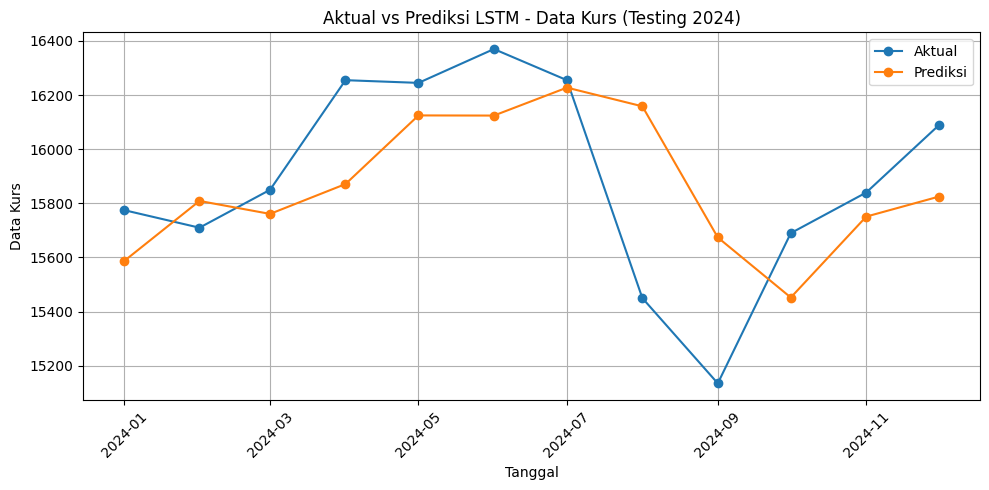

In [10]:
# ============================================================
# 8. PLOT AKTUAL VS PREDIKSI (TESTING 2024)
# ============================================================
for col in macro_cols:
    plot_df = test_plot_dict[col]

    plt.figure(figsize=(10, 5))
    plt.plot(plot_df["Tanggal"], plot_df["Aktual"], marker="o", label="Aktual")
    plt.plot(plot_df["Tanggal"], plot_df["Prediksi"], marker="o", label="Prediksi")
    plt.title(f"Aktual vs Prediksi LSTM - {col} (Testing 2024)")
    plt.xlabel("Tanggal")
    plt.ylabel(col)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

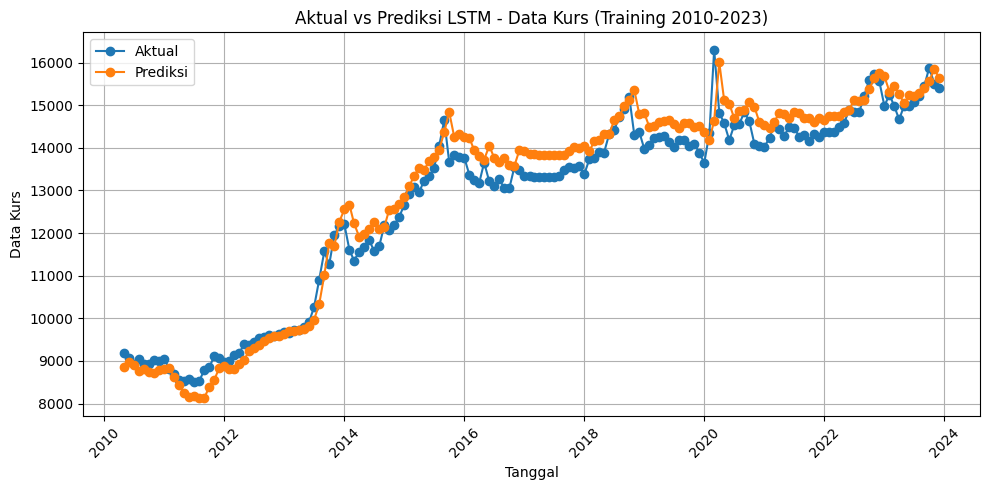

In [11]:
# ============================================================
# 8. PLOT AKTUAL VS PREDIKSI (tra 2024)
# ============================================================
for col in macro_cols:
    plot_df = train_plot_dict[col]

    plt.figure(figsize=(10, 5))
    plt.plot(plot_df["Tanggal"], plot_df["Aktual"], marker="o", label="Aktual")
    plt.plot(plot_df["Tanggal"], plot_df["Prediksi"], marker="o", label="Prediksi")
    plt.title(f"Aktual vs Prediksi LSTM - {col} (Training 2010-2023)")
    plt.xlabel("Tanggal")
    plt.ylabel(col)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

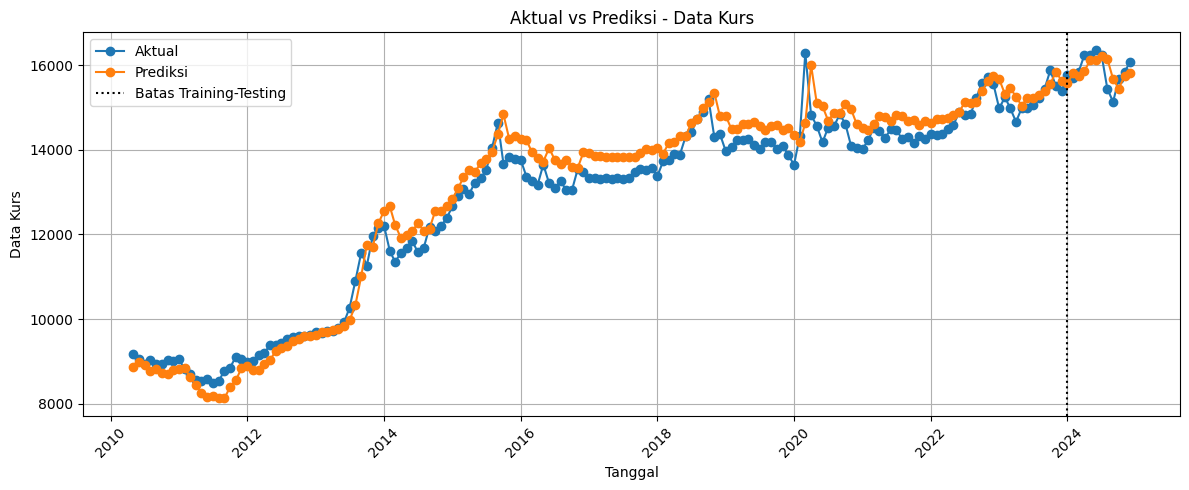

In [12]:
# ============================================================
# 8. PLOT GABUNGAN TRAINING + TESTING
# ============================================================
for col in macro_cols:
    train_df = train_plot_dict[col].copy()
    test_df  = test_plot_dict[col].copy()

    # gabungkan data training dan testing
    plot_df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

    # tentukan titik batas antara training dan testing
    split_date = test_df["Tanggal"].iloc[0]

    plt.figure(figsize=(12, 5))

    # plot aktual gabungan
    plt.plot(plot_df["Tanggal"], plot_df["Aktual"], marker="o", label="Aktual")

    # plot prediksi gabungan
    plt.plot(plot_df["Tanggal"], plot_df["Prediksi"], marker="o", label="Prediksi")

    # garis pemisah training dan testing
    plt.axvline(x=split_date, color="black", linestyle=":", label="Batas Training-Testing")

    plt.title(f"Aktual vs Prediksi - Data Kurs")
    plt.xlabel("Tanggal")
    plt.ylabel("Data Kurs")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [13]:
# ============================================================
# 9. BUAT TABEL FORECAST 2025
# ============================================================
future_dates_2025 = pd.date_range(start="2025-01-01", periods=12, freq="MS")
makro_2025 = pd.DataFrame({"Tanggal": future_dates_2025})

for col in macro_cols:
    makro_2025[col] = forecast_dict[col]

print("=== FORECAST 2025 ===")
print(makro_2025)

=== FORECAST 2025 ===
      Tanggal     Data Kurs
0  2025-01-01  15882.714844
1  2025-02-01  15777.703125
2  2025-03-01  15717.005859
3  2025-04-01  15664.185547
4  2025-05-01  15623.710938
5  2025-06-01  15593.134766
6  2025-07-01  15569.553711
7  2025-08-01  15551.364258
8  2025-09-01  15537.332031
9  2025-10-01  15526.489258
10 2025-11-01  15518.100586
11 2025-12-01  15511.608398


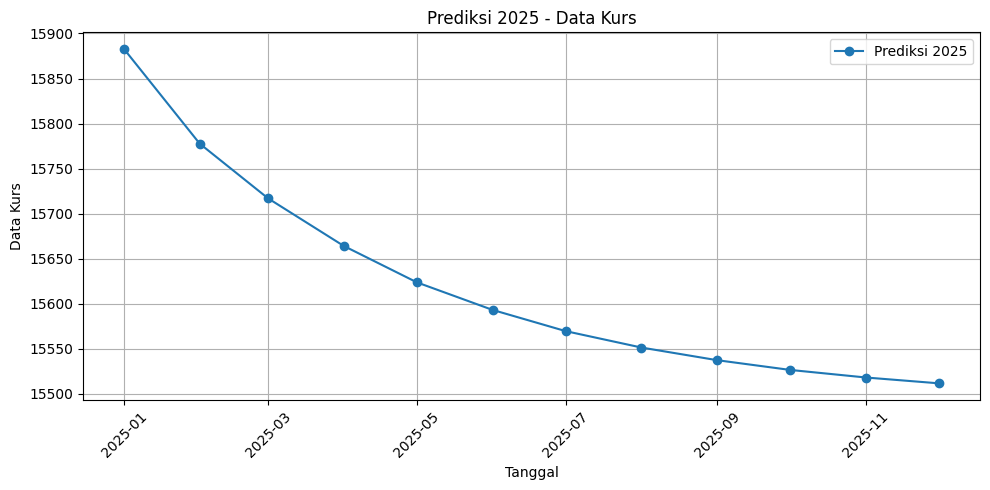

In [14]:
# ============================================================
# 10. PLOT FORECAST 2025
# ============================================================
for col in macro_cols:
    plt.figure(figsize=(10, 5))
    plt.plot(makro_2025["Tanggal"], makro_2025[col], marker="o", label="Prediksi 2025")
    plt.title(f"Prediksi 2025 - {col}")
    plt.xlabel("Tanggal")
    plt.ylabel(col)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

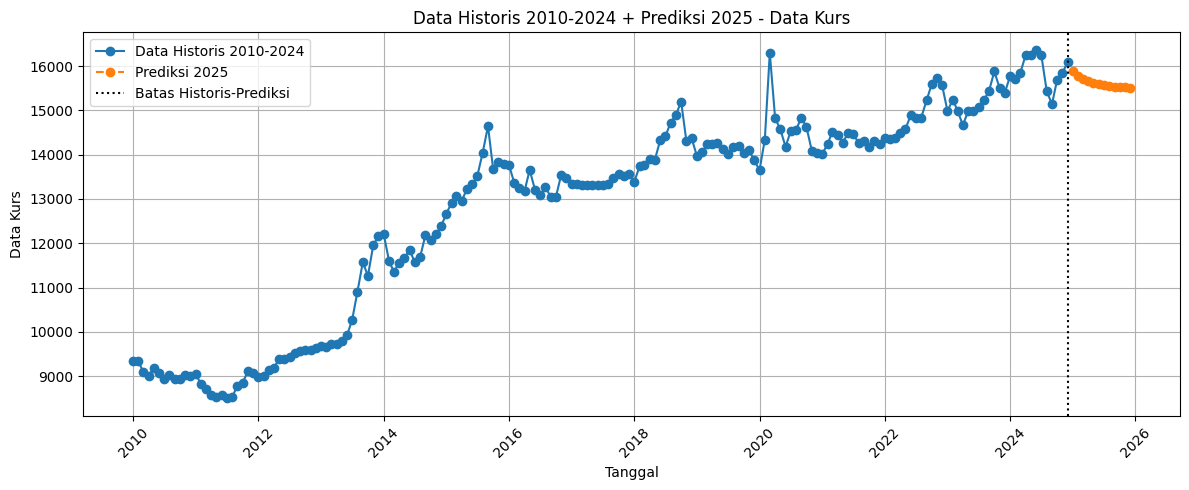

In [15]:
# ============================================================
# 11. PLOT DATA HISTORIS + DATA PREDIKSI 2025
# ============================================================

for col in macro_cols:

    plt.figure(figsize=(12, 5))

    # data historis
    plt.plot(df["Tanggal"], df[col], marker="o", label="Data Historis 2010-2024")

    # prediksi 2025
    plt.plot(makro_2025["Tanggal"], makro_2025[col],
             linestyle="--", marker="o", label="Prediksi 2025")

    # garis batas
    plt.axvline(pd.to_datetime("2024-12-01"), color="black", linestyle=":", label="Batas Historis-Prediksi")

    plt.title(f"Data Historis 2010-2024 + Prediksi 2025 - Data Kurs")
    plt.xlabel("Tanggal")
    plt.ylabel("Data Kurs")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [16]:
kurs_all = pd.concat([kurs, makro_2025], axis=0, ignore_index=True)

print(kurs_all)

       Tanggal     Data Kurs
0   2010-01-01   9350.000000
1   2010-02-01   9337.000000
2   2010-03-01   9090.000000
3   2010-04-01   9012.500000
4   2010-05-01   9175.000000
..         ...           ...
187 2025-08-01  15551.364258
188 2025-09-01  15537.332031
189 2025-10-01  15526.489258
190 2025-11-01  15518.100586
191 2025-12-01  15511.608398

[192 rows x 2 columns]


In [ ]:
path_simpan = '/content/drive/My Drive/Data Kurs All.xlsx'

# Simpan ke Excel
kurs_all.to_excel(path_simpan, index=False)